# PRA Train And Evaluate: Books

Reusable workflow for `stage4_books` using `pra_notebook_utils`:
inspect -> tokenize -> cache/backprop smoke test -> train -> plot -> evaluate.

The final parity check confirms this notebook follows the same metric and checkpoint contract as `pra_standalone.ipynb`.

In [1]:
from pathlib import Path
import sys

repo = Path.cwd()
if repo.name == "nb":
    repo = repo.parent
sys.path.insert(0, str(repo / "src"))
sys.path.insert(0, str(repo / "nb"))
sys.path.insert(0, str(repo))

import pra_notebook_utils as pnu

DATASET_STAGE = "stage4_books"
DATASET_LABEL = "Books"
WRITE_IMAGES_TO_DISK = False

## Runtime

In [2]:
runtime = pnu.configure_notebook(
    repo=repo,
    seed=7,
    write_images_to_disk=WRITE_IMAGES_TO_DISK,
)
runtime.as_dict()

{'repo': 'D:\\git\\rd\\pdattention',
 'seed': 7,
 'device': 'cuda',
 'write_images_to_disk': False,
 'python': '3.10.11',
 'torch_version': '2.12.1+cu126',
 'torch_cuda': '12.6',
 'cuda_available': True,
 'gpu': 'NVIDIA GeForce GTX 950M',
 'compute_capability': (5, 0)}

## Dataset Inspection

In [3]:
dataset_profile = pnu.inspect_dataset(
    DATASET_STAGE,
    data_dir=runtime.repo / "data",
)
dataset_profile

{'stage': 'stage4_books',
 'dataset_name': 'books',
 'size': 1,
 'sample_id': 'q4_1',
 'question': 'What does Alice follow? <REF_1>',
 'answer': 'white rabbit',
 'target_reference_ids': [1],
 'reference_tokens': ['<REF_1>'],
 'reference_uris': ['book://alice']}

## Capacity And Optimization Policy

In [4]:
policy = pnu.experiment_policy(dataset_profile["size"])
policy.as_dict()

{'d_model': 32,
 'n_layers': 2,
 'n_heads': 4,
 'batch_size': 1,
 'epochs': 20,
 'learning_rate': 0.001,
 'max_seq_len': 96,
 'estimated_optimizer_steps': 20}

## DataLoaders

In [5]:
datamodule, loader_summary = pnu.build_datamodule(
    DATASET_STAGE,
    runtime,
    policy=policy,
)
loader_summary

{'stage': 'stage4_books',
 'dataset_name': 'books',
 'size': 1,
 'sample_id': 'q4_1',
 'question': 'What does Alice follow? <REF_1>',
 'answer': 'white rabbit',
 'target_reference_ids': [1],
 'reference_tokens': ['<REF_1>'],
 'reference_uris': ['book://alice'],
 'train_size': 1,
 'validation_size': 1,
 'test_size': 1,
 'vocab_size': 102,
 'batch_shape': (1, 39)}

## Reference Tokenization

In [6]:
tokenization_check = pnu.inspect_reference_tokenization(datamodule)
tokenization_check

{'text': 'Use <REF_1> before <REF_2>.',
 'ids': [58, 88, 74, 5, 101, 5, 71, 74, 75, 84, 87, 74, 5, 102, 19],
 'decoded': 'Use <REF_1> before <REF_2>.',
 'reference_token_ids': {'<REF_0>': 100, '<REF_1>': 101},
 'round_trip_ok': True}

## Cache And Backpropagation Smoke Test

In [7]:
smoke_result = pnu.run_single_batch_smoke(datamodule, policy, runtime)
smoke_result

{'loss': 4.825412750244141,
 'cache_entries': 1,
 'model_parameters': 37248,
 'logits_shape': (1, 39, 103),
 'device': 'cuda'}

## Canonical PRA Training

In [8]:
training_result = pnu.train_dataset_workload(
    DATASET_STAGE,
    runtime,
    policy=policy,
)

[config] TrainConfig(experiment_name='stage4_books_size_1', output_dir='D:\\git\\rd\\pdattention\\out\\notebook_datasets', seed=7, device='cuda', dtype='float32', epochs=20, max_steps=None, batch_size=1, grad_accum_steps=1, learning_rate=0.001, weight_decay=0.0, warmup_steps=0, max_grad_norm=1.0, eval_every_steps=1, save_every_steps=20, log_every_steps=1, num_workers=0, pin_memory=False, persistent_workers=False, resume_from=None, use_tensorboard=False, save_metric_plots=False, use_wandb=False, use_clearml=False, mixed_precision=False, early_stopping_patience=None, dataset_stage='stage4_books', data_dir='D:\\git\\rd\\pdattention\\data', max_examples=None, max_seq_len=96, shuffle=True, resolver_config=ResolverServiceConfig(type='in_memory', options={}), cache_config=CacheServiceConfig(type='simple', options={}))


epoch 1/20:   0%|          | 0/1 [00:00<?, ?it/s]

[train_batch step=1] train_loss=4.9844 perplexity=146.1188 learning_rate=0.0010 grad_norm=1.0839 examples_per_second=6.0386 tokens_per_second=235.5058 gpu_memory_allocated=16.8135 epoch=1.0000 batch_in_epoch=1.0000 optimizer_step=1.0000 optimizer_updated=1.0000
[train step=1] train_loss=4.9844 perplexity=146.1188 learning_rate=0.0010 grad_norm=1.0839 examples_per_second=6.0386 tokens_per_second=235.5058 gpu_memory_allocated=16.8135
[val step=1] val_loss=4.8965 loss=4.8965 perplexity=133.8163 answer_accuracy=0.0000 reference_retrieval_accuracy=1.0000 expected_anchor_hit=0.0000 expansion_depth=1.0000 expanded_ref_count=1.0000 average_retrieved_tokens=46.0000 cache_hit_ratio=1.0000 latency=0.0183 examples_per_second=54.7423 tokens_per_second=2134.9508 gpu_memory_allocated=16.8545


epoch 1/20:   0%|          | 0/1 [00:00<?, ?it/s, step=1, loss=4.98, lr=0.001, ex/s=6.04, tok/s=236, val=4.9]

epoch 1/20: 100%|██████████| 1/1 [00:00<00:00,  3.97it/s, step=1, loss=4.98, lr=0.001, ex/s=6.04, tok/s=236, val=4.9]

...


[train step=20] train_loss=3.4398 perplexity=31.1800 learning_rate=0.0010 grad_norm=1.1005 examples_per_second=39.9006 tokens_per_second=1556.1221 gpu_memory_allocated=16.8135
[val step=20] val_loss=3.3713 loss=3.3713 perplexity=29.1162 answer_accuracy=0.0000 reference_retrieval_accuracy=1.0000 expected_anchor_hit=0.0000 expansion_depth=1.0000 expanded_ref_count=1.0000 average_retrieved_tokens=46.0000 cache_hit_ratio=1.0000 latency=0.0103 examples_per_second=97.3805 tokens_per_second=3797.8382 gpu_memory_allocated=16.8545


epoch 20/20:   0%|          | 0/1 [00:00<?, ?it/s, step=20, loss=3.44, lr=0.001, ex/s=39.9, tok/s=1.56e+3, val=3.37]

epoch 20/20: 100%|██████████| 1/1 [00:00<00:00,  7.64it/s, step=20, loss=3.44, lr=0.001, ex/s=39.9, tok/s=1.56e+3, val=3.37]

epoch 20/20: 100%|██████████| 1/1 [00:00<00:00,  7.58it/s, step=20, loss=3.44, lr=0.001, ex/s=39.9, tok/s=1.56e+3, val=3.37]

[train_epoch step=20] train_loss=3.4398 perplexity=31.1800 learning_rate=0.0010 grad_norm=1.1005 examples_per_second=7.5404 tokens_per_second=294.0764 gpu_memory_allocated=16.8135 epoch=20.0000 batches=1.0000 batch_step=20.0000 optimizer_step=20.0000 examples=1.0000 tokens=39.0000 duration_seconds=0.1326
[val_epoch step=20] val_loss=3.3713 loss=3.3713 perplexity=29.1162 answer_accuracy=0.0000 reference_retrieval_accuracy=1.0000 expected_anchor_hit=0.0000 expansion_depth=1.0000 expanded_ref_count=1.0000 average_retrieved_tokens=46.0000 cache_hit_ratio=1.0000 latency=0.0103 examples_per_second=97.3805 tokens_per_second=3797.8382 gpu_memory_allocated=16.8545 epoch=20.0000 optimizer_step=20.0000
[test step=20] test_loss=3.3713 loss=3.3713 perplexity=29.1162 answer_accuracy=0.0000 reference_retrieval_accuracy=1.0000 expected_anchor_hit=0.0000 expansion_depth=1.0000 expanded_ref_count=1.0000 average_retrieved_tokens=46.0000 cache_hit_ratio=1.0000 latency=0.0103 examples_per_second=97.5296 to

## Batch-Wise And Epoch-Wise Metrics

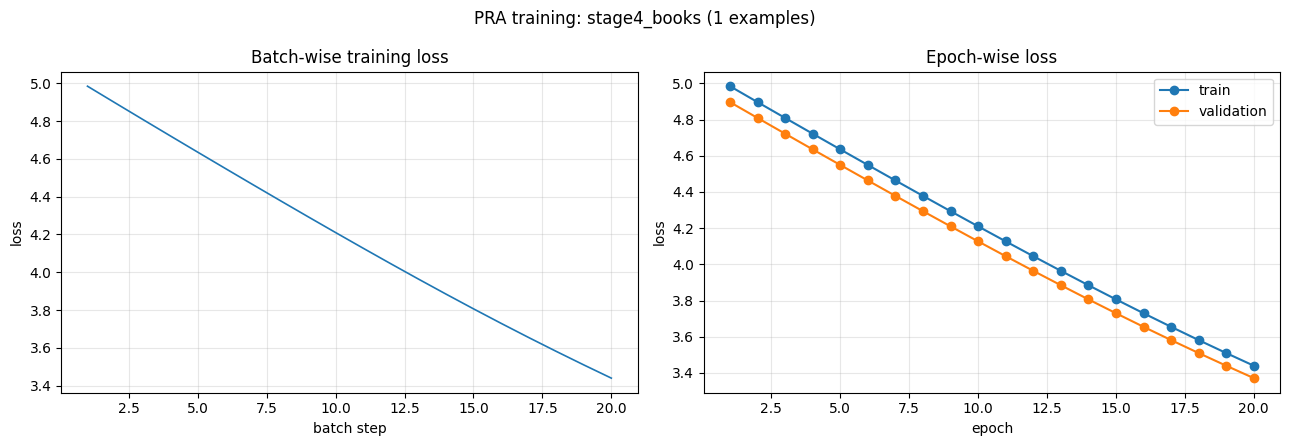

{'train_batches': 20,
 'train_epochs': 20,
 'validation_epochs': 20,
 'metrics_path': WindowsPath('D:/git/rd/pdattention/out/notebook_datasets/stage4_books_size_1/metrics.json'),
 'image_path': None}

In [9]:
progress_summary = pnu.plot_training_progress(
    training_result,
    write_to_disk=WRITE_IMAGES_TO_DISK,
)
progress_summary

## Evaluation Against Context Baselines

In [10]:
evaluation_results = pnu.evaluate_trained_workload(
    training_result,
    max_new_tokens=12,
)

PRA eval report (checkpoint)
variant       loss     accuracy   input_tokens   resolved_refs   ref_hit   anchor_hit   cache_hit   latency
no_refs        3.388   0.00%           25.0             0.0    0.00%       0.00%      0.00%    0.058s
full_context   3.388   0.00%           82.0             0.0    0.00%       0.00%      0.00%    0.062s
simple_rag     3.388   0.00%           76.0             0.0    0.00%       0.00%      0.00%    0.063s
pra            3.371   0.00%           25.0             1.0  100.00%       0.00%    100.00%    0.073s

Sample PRA output:
What does Alice follow? <REF_1>  A    rolt 


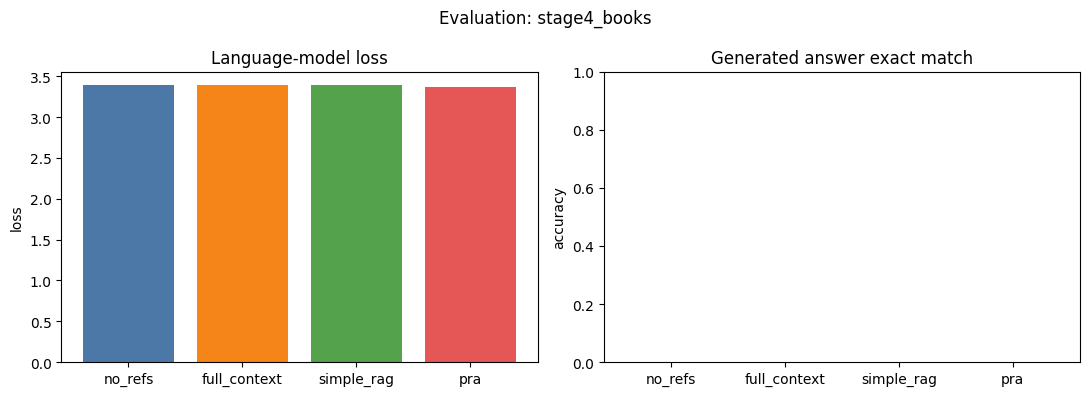

{'no_refs': 0.0, 'full_context': 0.0, 'simple_rag': 0.0, 'pra': 0.0}

In [11]:
evaluation_accuracy = pnu.plot_evaluation(
    evaluation_results,
    training_result,
    write_to_disk=WRITE_IMAGES_TO_DISK,
)
evaluation_accuracy

## Run Summary

In [12]:
run_summary = pnu.summarize_workload(training_result)
run_summary

{'dataset_stage': 'stage4_books',
 'size': 1,
 'parameters': 37184,
 'epochs': 20,
 'optimizer_steps': 20,
 'batch_steps': 20,
 'train_loss': 3.4397776126861572,
 'validation_loss': 3.371293783187866,
 'test_loss': 3.371293783187866,
 'test_perplexity': 29.116172714640147,
 'test_token_accuracy': None,
 'test_answer_accuracy': 0.0,
 'test_reference_accuracy': 1.0}

## Standalone Workflow Parity

In [13]:
parity = pnu.workflow_parity_report(training_result)
parity

{'uses_train_pra_model': True,
 'has_batch_timeseries': True,
 'has_epoch_timeseries': True,
 'has_validation_timeseries': True,
 'has_test_metrics': True,
 'batch_records': 20,
 'epoch_records': 20,
 'checkpoint_exists': True,
 'cuda_used': True}

## HTML Experiment Report

In [14]:
report_path = pnu.generate_html_report(
    training_result,
    runtime=runtime,
    evaluation_results=evaluation_results,
    dataset_details=loader_summary,
    model_name=f"standalone_{DATASET_STAGE}",
    qualifiers=(f"epochs{policy.epochs}", f"seq{policy.max_seq_len}"),
)
report_path

wrote HTML report: D:\git\rd\pdattention\out\reports\standalone_stage4_books_stage4_books_epochs20_seq96\index.html


WindowsPath('D:/git/rd/pdattention/out/reports/standalone_stage4_books_stage4_books_epochs20_seq96/index.html')